# Artificial Neuron and Activation Functions

This notebook explores the fundamental building block of a  neural network: the neuron.

The neuron is the computing element of the network, with input and output neurons acting as the interface between the network and its surrounding framework.

## Artificial Neuron

The artificial neuron, aka unit, is the building block of Deep Learning Networks. With a biological inspiration on brain neurons, it is a simple computational unit that is commonly grouped in layers to create neural networks. 

A simplified view of the brain neuron is presented in the following figure ([credit](https://pixabay.com/vectors/neuron-nerve-cell-axon-dendrite-296581/))

<div align="center">
 <img src="images/neuron.png" >
</div>

A very simplified description of a neuron's inner workings is as follows: the neuron receives its input through the dendrites. Synapses transmit the input signals to the cell body (soma), which processes them. If the processed signal reaches a certain threshold, the neuron generates an output signal that travels down the axon. At the end of the axon, synaptic terminals connect to the dendrites of other neurons through synapses.

<div align="center">
 <img src="images/artificial_neuron.png" >
</div>

The artificial neuron simulates this simplified description. It has inputs (analogous to dendrites), and the connections between the inputs and the neuron are represented by weights (analogous to synapses). The weighted inputs are summed and processed using an activation function $f$ (analogous to soma processing). The processed output is then passed to other neurons (analogous to the axon).

In the field of deep learning several activation functions have been proposed, in here we cover some of the most common ones.

## Activation functions

The role of an activation function is to transform the weighted sum of the inputs into a value that is fed to subsequent neurons. Activation functions introduce non-linearity into neural networks, enabling them to learn complex patterns.

Here, we explore some of the most common activation functions, providing both a Python implementation and Torch usage.

For a full list of activation functions supported in torch see [Non linear activations](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity)

### Sigmoid or logistic function

A sigmoid function is a squashing function in the sense that it "squashes" any real input into a bounded output between 0 and 1.


$f(x) = \large \frac{1}{1+e^{-x}}$

output range: $]0,1[$

Due to its output range, it can be interpreted as a probability in a binary class classifier with a single output.

The derivative of the sigmoid function is:

$f'(x) = f(x) (1 - f(x))$

Ref: Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by back-propagating errors.


In [27]:
import math
from matplotlib import pyplot as plt
import numpy as np

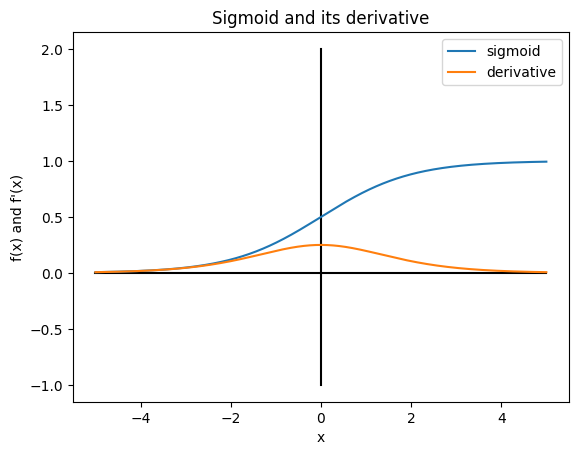

In [28]:
xx = np.linspace(-5, 5, 1000)

y = [1/(1+np.exp(-x)) for x in xx]
dy = [k*(1-k) for k in y ]

plt.plot((-5,5),(0,0), color='black')
plt.plot((0,0),(-1,2), color='black')
plt.plot(xx,y, label='sigmoid')
plt.plot(xx,dy, label = 'derivative')
plt.title("Sigmoid and its derivative")
plt.xlabel("x"), plt.ylabel("f(x) and f'(x)")
plt.legend()



#### Torch usage

In [29]:
import torch 

act = torch.nn.Sigmoid()
input = torch.randn(5)
output = act(input)

print(input)
print(output)

tensor([ 1.0714,  1.8820,  2.3735, -0.5336,  0.4867])
tensor([0.7449, 0.8678, 0.9148, 0.3697, 0.6193])


### Hyperbolic Tangent

$f(x) = tanh(x)$

output range: $]-1,1[$

Both $sigmoid$ and $tanh$ are *S* shaped functions, with the main difference being in the output range. The  advantage of the $tanh$ is that it provides zero-centered outputs due to its output range. Furthermore, $tanh$ has a steeper gradient compared to the $sigmoid$.

The derivative of the tanh function is:

$f'(x) = 1 - f(x)^2$

The derivative exposes a key issue with both these functions. As the absolute value of $x$ increases, the derivatives become smaller and smaller.  Since the weight updates are proportional to the derivatives, this means that very small updates are applied to the weights as the network trains.

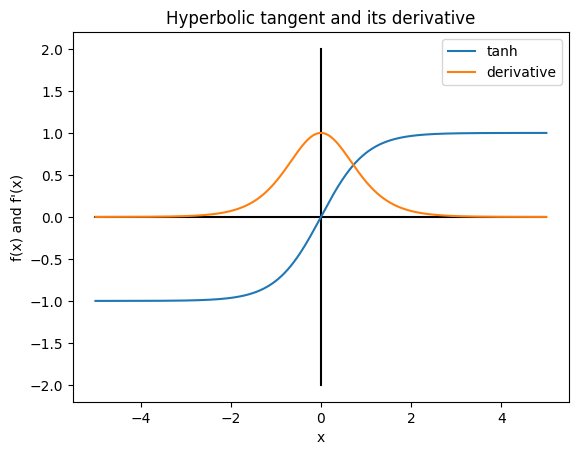

In [30]:
xx = np.linspace(-5, 5, 1000)

y = [math.tanh(x) for x in xx]
dy = [1-k*k for k in y]

plt.plot((-5,5),(0,0), color='black')
plt.plot((0,0),(-2,2), color='black')
plt.plot(xx,y, label ='tanh')
plt.plot(xx,dy, label = 'derivative')
plt.title("Hyperbolic tangent and its derivative")
plt.xlabel("x"), plt.ylabel("f(x) and f'(x)")
plt.legend()

#### Torch usage

In [31]:
import torch 

act = torch.nn.Tanh()
input = torch.randn(5)
output = act(input)

print(input)
print(output)

tensor([-1.2899,  0.9828, -1.4739,  1.3602, -1.1795])
tensor([-0.8591,  0.7543, -0.9003,  0.8764, -0.8273])


### ReLU: Rectified Linear Unit.

The ReLU activation function is the most common activation function today and is also one of the simplest. It is also probably the simplest activation function. Being piecewise linear makes it computationally efficient, and it has consistently provided  good results in CNNs.

Both sigmoid and tanh functions have shallow derivatives when the absolute value of the input is very large. ReLU does not suffer from that problem for positive inputs, having a constant derivative.

This is particularly meaningful in deep networks, as gradients tend to get smaller as they are backpropagated through multiple layers. With the $sigmoid$ or $tanh$ functions, if the outputs are large, their derivatives approach zero. This issue is known as the *vanishing gradient problem*.

$f(x)  = max(x, 0)$

output range: $[0, +\infty]$

The derivative of the ReLU is:

$f'(x) = \begin{cases}0  & \text{ if x < 0 }\\ 1 & \text{ if x >= 0 }\end{cases}$

The main issue with ReLU is that it sets all negative inputs to zero. This means that the derivative is also zero for negative inputs, implying that some weights and biases will not be updated during training. However, as mentioned earlier, ReLU still provides good results in practice.

Ref: Vinod Nair, Geoffrey E. Hinton,*Rectified Linear Units Improve Restricted Boltzmann Machines* [PDF](https://www.cs.toronto.edu/~fritz/absps/reluICML.pdf)

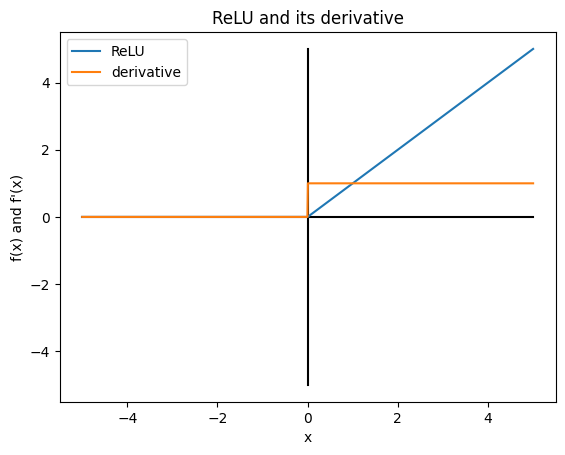

In [32]:
y = [max(k,0) for k in xx]

def drelu(x):

    if x < 0:
        return 0
    else:
        return 1
    
dy = [drelu(k) for k in xx]

plt.plot((-5,5),(0,0), color='black')
plt.plot((0,0),(-5,5), color='black')
plt.plot(xx,y, label = 'ReLU')
plt.plot(xx,dy, label = 'derivative')
plt.title("ReLU and its derivative")
plt.xlabel("x"), plt.ylabel("f(x) and f'(x)")
plt.legend()


### Leaky ReLU

Leaky ReLU is a modification of the ReLU function, where negative values are multiplied by a small constant instead of being set to zero.

$f(x) = \begin{cases} \alpha x, & \text{if}\ x < 0 \\ x, & \text{otherwise} \\ \end{cases}$


$f'(x) = \begin{cases}\alpha  & \text{ if x < 0 }\\ 1 & \text{ if x >= 0 }\end{cases}$


Tipically $a$ is set to a small value. TensorFlow uses $\alpha=0.3$ as default, whereas Pytorch uses $0.1$.

Ref: Andrew L. Maas, Awni Y. Hannun, Andrew Y. Ng, *Rectifier Nonlinearities Improve Neural Network Acoustic Models* [PDF](https://ai.stanford.edu/~amaas/papers/relu_hybrid_icml2013_final.pdf)

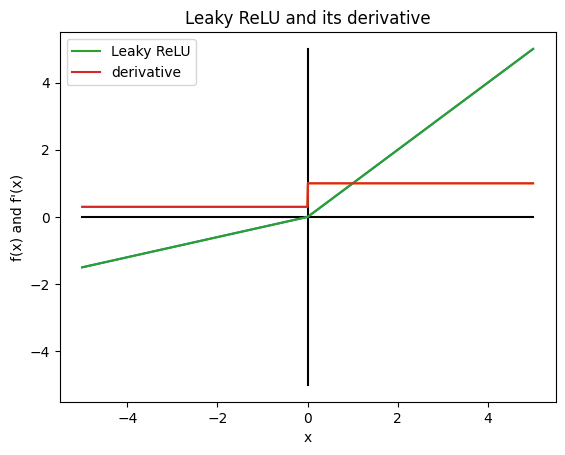

In [33]:
a = 0.3 # default value in tensorflow
y = [k if k > 0 else a*k for k in xx]


def dlrelu(x):

    if x < 0:
        return a
    else:
        return 1
    
dy = [dlrelu(k) for k in xx]

plt.plot((-5,5),(0,0), color='black')
plt.plot((0,0),(-5,5), color='black')
plt.plot(xx,y)
plt.plot(xx,dy)
plt.plot(xx,y, label = 'Leaky ReLU')
plt.plot(xx,dy, label = 'derivative')
plt.title("Leaky ReLU and its derivative")
plt.xlabel("x"), plt.ylabel("f(x) and f'(x)")
plt.legend()

#### Torch usage

In [34]:
import torch 

actR = torch.nn.ReLU()
input = torch.randn(5)
output_ReLU = actR(input)

actLR = torch.nn.LeakyReLU()
outupt_LReLU = actLR(input)

print(input)
print(output_ReLU)
print(outupt_LReLU)

tensor([-0.8313, -0.0771, -0.4321,  0.1882,  1.0972])
tensor([0.0000, 0.0000, 0.0000, 0.1882, 1.0972])
tensor([-8.3131e-03, -7.7122e-04, -4.3212e-03,  1.8820e-01,  1.0972e+00])


### Swish or SILU

Swish, introduced by Google Brain in 2017, is a product of the identity function and the sigmoid function. The output is the product of the input $x$ by the sigmoid of $x$.

$f(x) = x \large \frac{1}{1+e^{-x}}$

The derivative is given by:

$f'(x) = f (x) + \large \frac{1}{1+e^{-x}} (1 − f (x))$

Ref: Prajit Ramachandran, Barret Zoph, Quoc V. Le, *Searching for Activation Functions* [PDF](https://arxiv.org/abs/1710.05941)


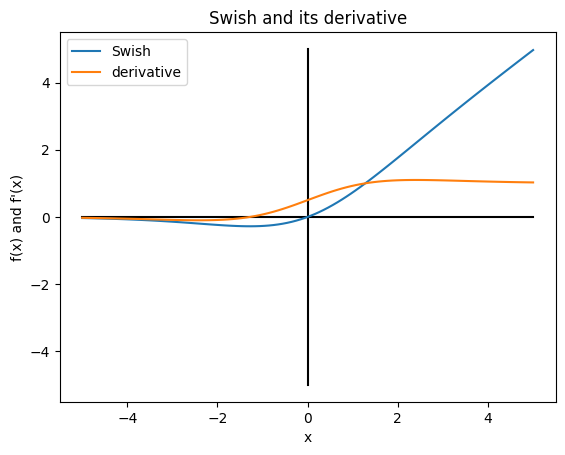

In [35]:
xx = np.linspace(-5, 5, 100)

y = [x * 1/(1+np.exp(-x)) for x in xx]

dy = [x * 1/(1+np.exp(-x)) +  1/(1+np.exp(-x)) * (1 - x * 1/(1+np.exp(-x)))  for  x in xx]

plt.plot((-5,5),(0,0), color='black')
plt.plot((0,0),(-5,5), color='black')
plt.plot(xx,y, label = 'Swish')
plt.plot(xx,dy, label = 'derivative')
plt.title("Swish and its derivative")
plt.xlabel("x"), plt.ylabel("f(x) and f'(x)")
plt.legend()

Torch usage

In [36]:
import torch 

act = torch.nn.SiLU()
input = torch.randn(5)
output = act(input)

print(input)
print(output)

tensor([-0.3128, -1.1279, -1.8651, -0.5677, -1.1411])
tensor([-0.1321, -0.2758, -0.2501, -0.2054, -0.2763])
